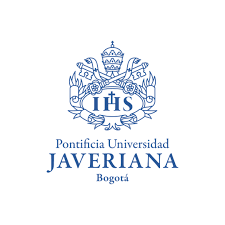
***Pontificia Universidad Javeriana***
# **Procesamiento de Alto Volumen de Datos**

### Taller: **Tratamiento de Datos y Machine Learning con PySpark**

Autor: Juan David Ordoñez Jimenez

Fecha de Inicio: 13/04/2026

Fecha actual: 27/04/2026

## **Problemática**

Se tiene que el tratamiento del agua debe ser indispensable para garantizar la pureza y la calidad. Uno de los elementos significativos es aplicar los conceptos de los Procesamientos de Datos en Alto Volúmen para solucionar este tipo de problemas que afectan la salud publica. El presente ejemplo tiene como propósito tener en cuenta una metodogología para aplicar el PAVD para solucionar o diagnósticar la calidad del agua en la INDIA.

## **Objetivo**

# Análisis y modelado de calidad del agua mediante WQI y redes neuronales en Keras

Este cuaderno desarrolla un flujo completo de análisis de calidad del agua a partir de variables fisicoquímicas y microbiológicas. El objetivo principal es calcular un índice de calidad del agua, conocido como `WQI` (*Water Quality Index*), y posteriormente entrenar un modelo de regresión en Keras capaz de predecir dicho índice a partir de las características del agua.

El proceso incluye la carga y limpieza de datos, tratamiento de valores faltantes, análisis exploratorio, visualización de parámetros, construcción de puntuaciones individuales de calidad, cálculo del WQI, clasificación de calidad del agua, visualización geográfica y entrenamiento de modelos de Machine Learning.

El cuaderno conserva la lógica original del cálculo del WQI, pero incorpora mejoras metodológicas importantes como imputación por mediana, transformación logarítmica para variables con alta dispersión, normalización de datos, uso de validación, `EarlyStopping` y evaluación sobre datos de prueba.


## **Metodología**

1.- Importación de los datos (datos en diferentes formatos)

2.- Preprocesamiento y limpieza de valores nulos, cambio de datos, EDA, medidas estadísticas.

3.- Entrenamiento de modelos: RL (MLlib), tensores (KERAS); la idea es predecir la calidad del agua en la INDIA.

4.- Evaluación de los modelos: medidas de rendimiento tales como: precisión (precision), exactitud (accuracy), recall, F1 Score,entre otras.

5.- Se tiene como referencia de la calidad de los parámetros del agua, la referencia: https://www.intechopen.com/chapters/69568

## **1.- Importación de bibliotecas**
En esta sección se importan las librerías necesarias para el procesamiento de datos, visualización, análisis geográfico y modelado con redes neuronales. Se utilizan herramientas como `PySpark` para el manejo inicial del dataset, `Pandas` y `NumPy` para la manipulación de datos, `Matplotlib` y `Seaborn` para visualizaciones, y `Keras` para la construcción del modelo de regresión.

También se configura una sesión de Spark, la cual permite trabajar con los datos mediante DataFrames distribuidos. Aunque el conjunto de datos no es extremadamente grande, el uso de Spark permite estructurar el flujo de procesamiento de forma ordenada y escalable.

In [1]:
# Levantamiento de variables de entorno pip
import os

import sys

sys.path.append('/usr/lib/python3/dist-packages/')
os.environ["PYSPARK_PYTHON"] = "/usr/bin/python3"
os.environ["PYSPARK_DRIVER_PYTHON"] = "/usr/bin/python3"

import numpy as np

import pandas as pd

import seaborn as sns

import matplotlib.pyplot as plt

from pylab import *

import findspark

findspark.init()

import pyspark.sql.functions as F

from pyspark import SparkConf, SparkContext

from pyspark.sql import SQLContext

from pyspark.sql import SparkSession

from pyspark.sql.types import *

from pyspark.ml.feature import Imputer


In [2]:
### Levantamiento de sesión SPARK
configura = SparkConf()

configura.set("spark.scheduler.mode","FAIR")
configura.set("spark.scheduler.allocation","/Almacen/Spark/conf/fairscheduler.xml")
configura.setMaster("spark://10.43.97.177:7077")

configura.setAppName("Calidad_Agua_Ordoñez")

sparkO = SparkSession.builder.config(conf=configura).getOrCreate()

SQLContext(sparkContext=sparkO.sparkContext, sparkSession=sparkO)

sparkContextoO = sparkO.sparkContext.getOrCreate()

print("Sesion creada: ProcesamientoDatos04")

sparkO

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/27 00:38:46 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Sesion creada: ProcesamientoDatos04


## **2. Carga del conjunto de datos**

En esta sección se carga el archivo `waterquality.csv`, el cual contiene mediciones de calidad del agua en diferentes estaciones y estados de India. El dataset incluye variables de ubicación y variables relacionadas con la calidad del agua, como temperatura, oxígeno disuelto, pH, conductividad, demanda bioquímica de oxígeno, nitratos, nitritos y coliformes fecales.

Las primeras filas del dataset permiten verificar que la carga fue exitosa y observar la estructura inicial de las columnas.

In [3]:
df00 = sparkO.read.format("csv").option("header", "true").load("file:///Almacen/waterquality.csv")
df00 = df00.replace("NA", None)

df00.show(5)

+------------+--------------------+-----------+----+---+---+------------+---+-------------------+--------------+--------------+
|STATION CODE|           LOCATIONS|      STATE|TEMP| DO| pH|CONDUCTIVITY|BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|TOTAL_COLIFORM|
+------------+--------------------+-----------+----+---+---+------------+---+-------------------+--------------+--------------+
|        1312|GODAVARI AT JAYAK...|MAHARASHTRA|29.2|6.4|8.1|         735|3.4|                  2|             3|            73|
|        2177|GODAVARI RIVER NE...|MAHARASHTRA|24.5|  6|  8|         270|3.1|                  2|            72|           182|
|        2182|GODAVARI RIVER AT...|MAHARASHTRA|25.8|5.5|7.8|         355|4.2|                  9|            59|           133|
|        2179|GODAVARI RIVER AT...|MAHARASHTRA|24.8|5.5|7.8|         371|5.6|               3.55|            90|           283|
|        2183|GODAVARI RIVER AT...|MAHARASHTRA|25.7|5.7|7.9|         294|3.2|               2.69|       

## **3.- Análisis y Preparación de Datos**
Antes de realizar transformaciones, se revisa la estructura general del dataset. Se inspeccionan los nombres de las columnas, la cantidad de registros y algunas estadísticas descriptivas de cada variable.

Esta etapa permite identificar posibles problemas iniciales, como columnas numéricas almacenadas como texto, valores faltantes representados como `"NA"` y variables con rangos muy amplios o valores extremos.

Se presentan datos (csv) con los diferentes parámetros de los rios de la India. Cada parámetro es el promedio de los valores medidos en un período de tiempo. Los datos han sido extraidos de la web oficial de la India (RiverIndia)

- Tipos de datos: coherencia de tipo de datos, transformación
- Columnas: conocimiento de las columnas, eliminación.
- Análisis de datos nulos o imposibles: concimiento.

In [4]:
##Conocimiento de las columnas
df00.columns

['STATION CODE',
 'LOCATIONS',
 'STATE',
 'TEMP',
 'DO',
 'pH',
 'CONDUCTIVITY',
 'BOD',
 'NITRATE_N_NITRITE_N',
 'FECAL_COLIFORM',
 'TOTAL_COLIFORM']

- STATION CODE: Código de estación de medida
- LOCATIONS: ubicaciones de los rios
- STATE: Estado de la india
- TEMP: Temperatura del agua en °C
- DO: Oxigeno Disuelto (mg/L). Concentraciones altas de oxigeno representa mejor calidad del agua.
- pH: Logaritmo negativo de la concentración de hidrógeno. Número adimensional para indicar la acidez del agua.
- CONDUCTIVITY: Mide la habilidad de una solución conducir corriente. El agua pura NO es conductora de corriente.
- BOD: Bacterias y otros microorganismos que utilizan sustancias orgánicas como alimento: Demanda Bioquímica de Oxigeno. Mayor cantidad de material orgánico mayor BOD.
- NITRATE_N_NITRITE_N: Nitratos/Nitritos "nitrógeno". Altas concentraciones Nitrogeno en la superficie del agua puede estimular el rápido crecimiento de algas las cuales degradan la calidad del agua (mg/L).
- FECAL_COLIFORM: Promedio de bacterias coliformes: excresiones.
- TOTAL_COLIFORM']: Se eliminará pues no aporta al estudio de predicción de la calidad del agua.

In [5]:
#se verifican los tipos de datos de las columnas
df00.dtypes

[('STATION CODE', 'string'),
 ('LOCATIONS', 'string'),
 ('STATE', 'string'),
 ('TEMP', 'string'),
 ('DO', 'string'),
 ('pH', 'string'),
 ('CONDUCTIVITY', 'string'),
 ('BOD', 'string'),
 ('NITRATE_N_NITRITE_N', 'string'),
 ('FECAL_COLIFORM', 'string'),
 ('TOTAL_COLIFORM', 'string')]

In [6]:
columnas_numericas = [
    'TEMP',
    'DO',
    'pH',
    'CONDUCTIVITY',
    'BOD',
    'NITRATE_N_NITRITE_N',
    'FECAL_COLIFORM',
    'TOTAL_COLIFORM'
]
#se ejecuta la transformacion a columnas numericas que eran de tipo string
for columna in columnas_numericas:
    df00 = df00.withColumn(columna, df00[columna].cast(FloatType()))

In [7]:
for valor in df00.columns:
  
  df00.describe([valor]).show()

+-------+-----------------+
|summary|     STATION CODE|
+-------+-----------------+
|  count|              534|
|   mean|2052.516853932584|
| stddev|755.2178560086894|
|    min|             1023|
|    max|               41|
+-------+-----------------+



+-------+-------------------+
|summary|          LOCATIONS|
+-------+-------------------+
|  count|                534|
|   mean|               NULL|
| stddev|               NULL|
|    min|          AHMEDABAD|
|    max|ZUARI AT PANCHAWADI|
+-------+-------------------+

+-------+--------------+
|summary|         STATE|
+-------+--------------+
|  count|           534|
|   mean|          NULL|
| stddev|          NULL|
|    min|ANDHRA PRADESH|
|    max|   WEST BENGAL|
+-------+--------------+



+-------+------------------+
|summary|              TEMP|
+-------+------------------+
|  count|               529|
|   mean|25.241398822157056|
| stddev|3.4480130774354945|
|    min|              10.5|
|    max|              33.8|
+-------+------------------+

+-------+------------------+
|summary|                DO|
+-------+------------------+
|  count|               532|
|   mean|  6.38981203334336|
| stddev|1.6228617240309144|
|    min|               0.0|
|    max|              16.3|
+-------+------------------+

+-------+------------------+
|summary|                pH|
+-------+------------------+
|  count|               534|
|   mean| 7.798127372613114|
| stddev|0.6499503850220179|
|    min|               6.3|
|    max|              14.7|
+-------+------------------+

+-------+------------------+
|summary|      CONDUCTIVITY|
+-------+------------------+
|  count|               504|
|   mean| 684.9761904761905|
| stddev|1769.3297602834873|
|    min|              39.0|
|    max|  

Las estadísticas iniciales muestran que algunas variables presentan valores mínimos, máximos o conteos que deben interpretarse con cuidado, ya que inicialmente los datos fueron cargados como texto. Por esta razón, antes de obtener conclusiones definitivas, es necesario convertir las columnas numéricas a tipo `FloatType`.

También se observa que algunas variables, como `CONDUCTIVITY` y `FECAL_COLIFORM`, pueden presentar valores muy altos en comparación con otras variables. Esto será importante más adelante para el entrenamiento del modelo.

## **Visualización de los DATOS NULOS**

In [8]:
df00.select([F.count(F.when(F.isnan(c) | F.col(c).isNull(), c)).alias(c) for c in df00.columns]).show()

+------------+---------+-----+----+---+---+------------+---+-------------------+--------------+--------------+
|STATION CODE|LOCATIONS|STATE|TEMP| DO| pH|CONDUCTIVITY|BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|TOTAL_COLIFORM|
+------------+---------+-----+----+---+---+------------+---+-------------------+--------------+--------------+
|           0|        0|    0|   5|  2|  0|          30|  6|                  2|            82|            39|
+------------+---------+-----+----+---+---+------------+---+-------------------+--------------+--------------+



## **4. Limpieza de datos e imputación de valores faltantes**

En esta sección se realiza una limpieza importante del dataset. Inicialmente, algunos valores faltantes estaban representados como texto `"NA"`, por lo que no eran reconocidos directamente como valores nulos por Spark. Para corregir esto, se reemplazan dichos valores por nulos reales.

con: df00 = df00.replace("NA", None)

En la parte anterior, las columnas numéricas se convierten a tipo `FloatType` para poder visualuzar bien la dispercion de los datos y el verdadero conteo de nulos, lo cual permite realizar cálculos, comparaciones y modelado correctamente. 

También se elimina la columna `TOTAL_COLIFORM`, ya que no se utiliza directamente en el cálculo del índice WQI y presenta una cantidad considerable de valores faltantes.

Para evitar perder registros, los valores nulos de las variables numéricas utilizadas en el análisis se imputan mediante la mediana. Se eligió la mediana porque es más robusta frente a valores extremos que el promedio, especialmente en variables como `CONDUCTIVITY` y `FECAL_COLIFORM`.

In [9]:

#Eliminar columna TOTAL_COLIFORM
df01 = df00.drop('TOTAL_COLIFORM')

# 4. Imputar nulos con la mediana
columnas_imputar = [
    'TEMP',
    'DO',
    'pH',
    'CONDUCTIVITY',
    'BOD',
    'NITRATE_N_NITRITE_N',
    'FECAL_COLIFORM'
]

imputer = Imputer(
    inputCols=columnas_imputar,
    outputCols=[columna + "_imputed" for columna in columnas_imputar]
).setStrategy("median")

df_imputado = imputer.fit(df01).transform(df01)

# Reemplazar columnas originales por columnas imputadas
for columna in columnas_imputar:
    df_imputado = df_imputado.drop(columna).withColumnRenamed(columna + "_imputed", columna)

# Guardar dataframe limpio final
df01 = df_imputado

# Verificar que ya no haya nulos
df01.select([
    F.count(F.when(F.col(c).isNull(), c)).alias(c)
    for c in df01.columns
]).show()

# Mostrar primeras filas limpias
df01.show(5)

+------------+---------+-----+----+---+---+------------+---+-------------------+--------------+
|STATION CODE|LOCATIONS|STATE|TEMP| DO| pH|CONDUCTIVITY|BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|
+------------+---------+-----+----+---+---+------------+---+-------------------+--------------+
|           0|        0|    0|   0|  0|  0|           0|  0|                  0|             0|
+------------+---------+-----+----+---+---+------------+---+-------------------+--------------+

+------------+--------------------+-----------+----+---+---+------------+---+-------------------+--------------+
|STATION CODE|           LOCATIONS|      STATE|TEMP| DO| pH|CONDUCTIVITY|BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|
+------------+--------------------+-----------+----+---+---+------------+---+-------------------+--------------+
|        1312|GODAVARI AT JAYAK...|MAHARASHTRA|29.2|6.4|8.1|       735.0|3.4|                2.0|           3.0|
|        2177|GODAVARI RIVER NE...|MAHARASHTRA|24.5|6.0|8.0|       

## **5. Visualización inicial de parámetros de calidad del agua**

En esta sección se grafican algunas variables relevantes del dataset con el fin de observar su comportamiento general a lo largo de las muestras. Estas visualizaciones permiten identificar variaciones, posibles valores extremos y diferencias de escala entre los parámetros.

Las gráficas no representan todavía una clasificación final de calidad, sino una exploración visual de las variables que posteriormente serán utilizadas para calcular las puntuaciones individuales y el índice WQI.

In [10]:
df01.createOrReplaceTempView("df01_sql")

do_parametro = sparkO.sql("SELECT DO FROM df01_sql")
do_parametro = [fila["DO"] for fila in do_parametro.collect()]

ph_parametro = sparkO.sql("SELECT pH FROM df01_sql")
ph_parametro = [fila["pH"] for fila in ph_parametro.collect()]

conductivity_parametro = sparkO.sql("SELECT CONDUCTIVITY FROM df01_sql")
conductivity_parametro = [fila["CONDUCTIVITY"] for fila in conductivity_parametro.collect()]

bod_parametro = sparkO.sql("SELECT BOD FROM df01_sql")
bod_parametro = [fila["BOD"] for fila in bod_parametro.collect()]

nitrate_parametro = sparkO.sql("SELECT NITRATE_N_NITRITE_N FROM df01_sql")
nitrate_parametro = [fila["NITRATE_N_NITRITE_N"] for fila in nitrate_parametro.collect()]

fecal_parametro = sparkO.sql("SELECT FECAL_COLIFORM FROM df01_sql")
fecal_parametro = [fila["FECAL_COLIFORM"] for fila in fecal_parametro.collect()]

print("DO:", do_parametro)
print("pH:", ph_parametro)
print("CONDUCTIVITY:", conductivity_parametro)
print("BOD:", bod_parametro)
print("NITRATE_N_NITRITE_N:", nitrate_parametro)
print("FECAL_COLIFORM:", fecal_parametro)

DO: [6.400000095367432, 6.0, 5.5, 5.5, 5.699999809265137, 4.5, 5.199999809265137, 5.599999904632568, 5.199999809265137, 6.5, 6.199999809265137, 6.400000095367432, 6.199999809265137, 6.5, 7.0, 6.400000095367432, 6.599999904632568, 5.5, 6.900000095367432, 5.699999809265137, 3.200000047683716, 6.699999809265137, 4.400000095367432, 6.099999904632568, 6.599999904632568, 4.099999904632568, 6.0, 5.599999904632568, 6.099999904632568, 5.800000190734863, 6.199999809265137, 6.099999904632568, 5.900000095367432, 8.5, 8.800000190734863, 8.100000381469727, 8.399999618530273, 8.699999809265137, 8.199999809265137, 8.699999809265137, 6.900000095367432, 5.400000095367432, 7.699999809265137, 9.0, 8.0, 8.199999809265137, 7.800000190734863, 7.300000190734863, 7.900000095367432, 7.300000190734863, 7.900000095367432, 7.5, 6.300000190734863, 8.0, 8.199999809265137, 8.699999809265137, 8.399999618530273, 8.5, 8.399999618530273, 8.399999618530273, 8.300000190734863, 7.800000190734863, 7.699999809265137, 8.600000

### 5.1 Oxígeno disuelto y pH

Esta gráfica compara el comportamiento del oxígeno disuelto (`DO`) y el `pH` a lo largo de las muestras. Ambas variables son importantes en el análisis de calidad del agua.

El oxígeno disuelto indica la cantidad de oxígeno disponible en el agua, mientras que el pH permite conocer si el agua presenta condiciones ácidas, neutras o básicas. En general, valores adecuados de oxígeno disuelto y un pH cercano al rango aceptable son indicadores favorables para la calidad del agua.

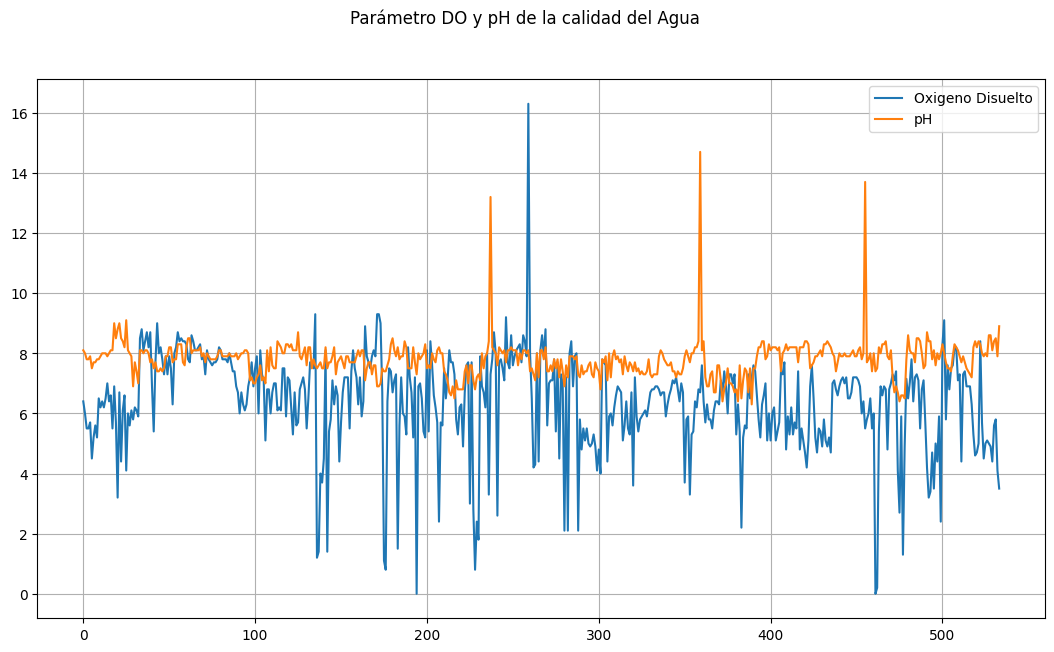

In [11]:
tam = len(do_parametro)
fig, ax1 = plt.subplots(num=None, figsize=(13,7), facecolor='w', edgecolor='k')
ax1.plot(range(0,tam), do_parametro, label='Oxigeno Disuelto')
ax1.plot(range(0,tam), ph_parametro, label='pH')
fig.suptitle('Parámetro DO y pH de la calidad del Agua')
legend=ax1.legend()
plt.grid()
plt.show()

En la gráfica se observa que el pH suele mantenerse en un rango relativamente estable, mientras que el oxígeno disuelto presenta mayor variabilidad entre las muestras. Esta diferencia muestra que algunos parámetros tienen comportamientos más constantes que otros dentro del conjunto de datos.

### 5.2 BOD y nitratos/nitritos

Esta gráfica muestra la relación visual entre la demanda bioquímica de oxígeno (`BOD`) y la concentración de nitratos y nitritos (`NITRATE_N_NITRITE_N`). Estas variables son relevantes porque pueden estar asociadas con contaminación orgánica, descargas residuales o presencia de nutrientes en el agua.

Un valor alto de `BOD` puede indicar mayor presencia de materia orgánica, mientras que valores elevados de nitratos o nitritos pueden relacionarse con contaminación por fertilizantes, residuos agrícolas o aguas residuales.

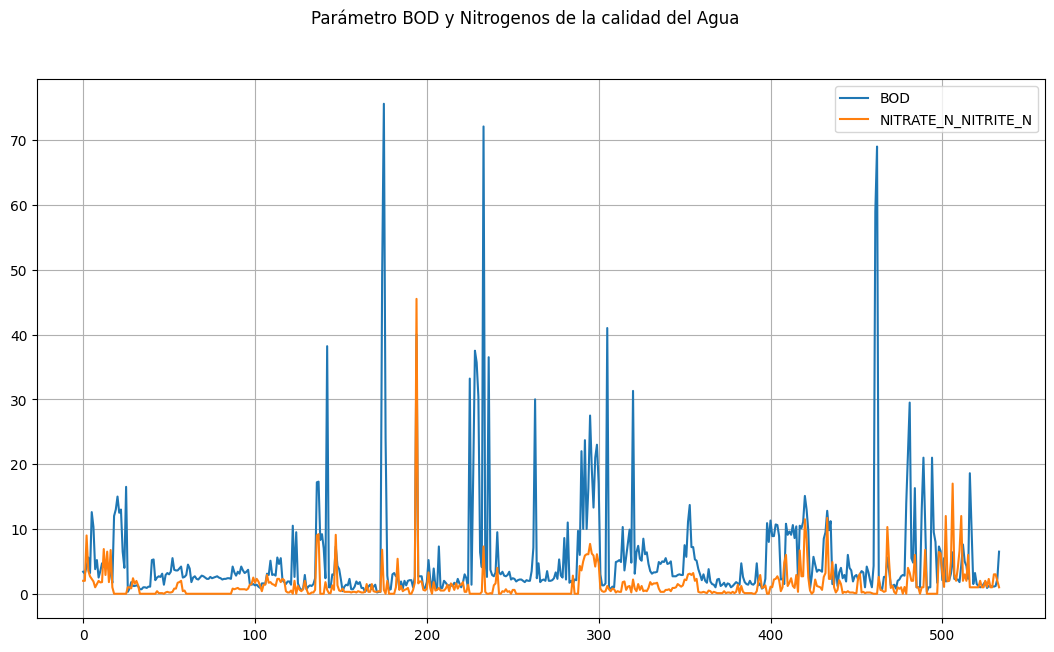

In [12]:
tam = len(bod_parametro)
fig, ax1 = plt.subplots(num=None, figsize=(13,7), facecolor='w', edgecolor='k')
ax1.plot(range(0,tam), bod_parametro, label='BOD')
ax1.plot(range(0,tam), nitrate_parametro, label='NITRATE_N_NITRITE_N')
fig.suptitle('Parámetro BOD y Nitrogenos de la calidad del Agua')
legend=ax1.legend()
plt.grid()
plt.show()

La gráfica permite observar variaciones entre las muestras y posibles picos en algunos puntos. Estos comportamientos justifican la necesidad de transformar cada variable en una puntuación de calidad antes de calcular el índice WQI.

### 5.3 Conductividad y coliformes fecales

Esta gráfica compara la conductividad eléctrica (`CONDUCTIVITY`) con los coliformes fecales (`FECAL_COLIFORM`). Ambas variables pueden presentar valores elevados y alta dispersión.

La conductividad está relacionada con la cantidad de sales o sólidos disueltos en el agua, mientras que los coliformes fecales son un indicador microbiológico asociado a contaminación fecal. Debido a sus escalas y posibles valores extremos, estas variables requieren especial atención durante el análisis y el modelado.

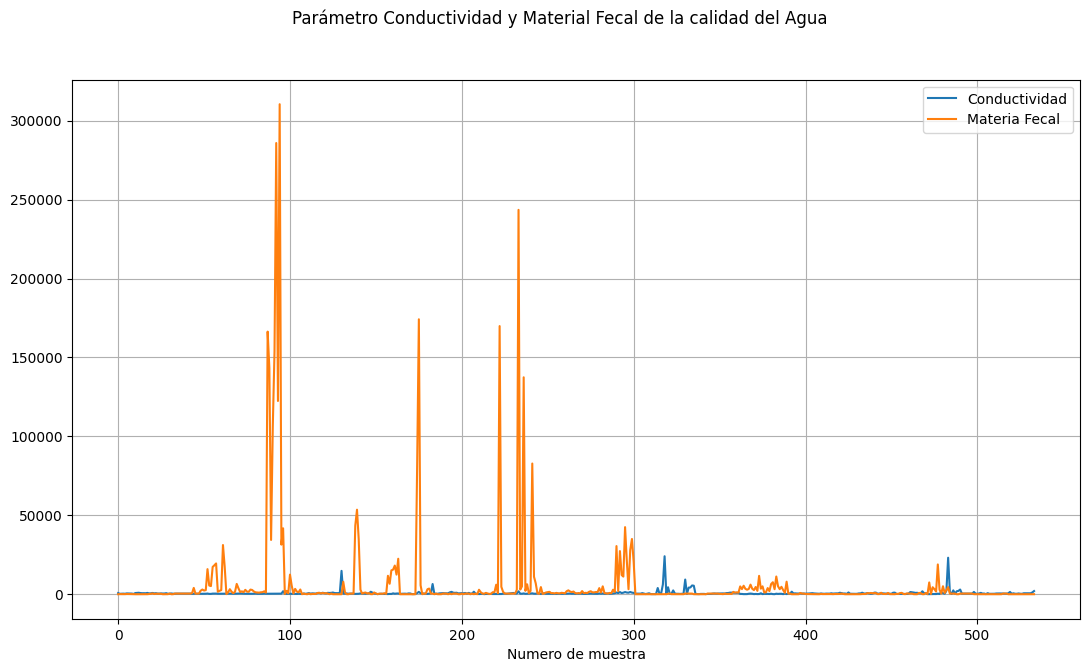

In [13]:
tam = len(conductivity_parametro)

fig, ax1 = plt.subplots(num=None, figsize=(13,7), facecolor='w', edgecolor='k')

ax1.plot(range(0,tam), conductivity_parametro, label='Conductividad')

ax1.plot(range(0,tam), fecal_parametro, label='Materia Fecal')

fig.suptitle('Parámetro Conductividad y Material Fecal de la calidad del Agua')

legend=ax1.legend()

plt.xlabel("Numero de muestra")

plt.grid()

plt.show()

Se observa que estas variables pueden tener diferencias importantes de escala y presencia de valores altos. Esto explica por qué más adelante se aplicó una transformación logarítmica (`log1p`) a `CONDUCTIVITY` y `FECAL_COLIFORM` antes de entrenar el modelo de regresión.

## **6. Cálculo de puntuaciones individuales de calidad**

En esta sección se transforma cada variable original en una puntuación individual de calidad. Estas puntuaciones se nombran con el prefijo `qr` y permiten llevar diferentes parámetros a una escala común.

Cada variable recibe una puntuación según rangos previamente definidos. Por ejemplo, un valor adecuado de pH recibe una puntuación alta, mientras que valores alejados del rango aceptable reciben una puntuación menor. La misma lógica se aplica a variables como oxígeno disuelto, conductividad, BOD, nitratos y coliformes fecales.

Estas puntuaciones son importantes porque sirven como base para calcular el índice final WQI.

### Puntuación de pH

El pH se evalúa considerando como mejores aquellos valores cercanos al rango aceptable para el agua. Valores dentro del intervalo esperado reciben una puntuación alta, mientras que valores más alejados reciben puntuaciones menores.

In [14]:
df02 = df01.withColumn("qrPH", F.when((df01.pH>=7) & (df01.pH<=8.5),100).

 when(((df01.pH>=6.8) & (df01.pH<6.9)) | ((df01.pH>8.5) & (df01.pH<8.6)), 80).

 when(((df01.pH>=6.7) & (df01.pH<6.8)) | ((df01.pH>=8.6) & (df01.pH<8.8)), 60).

 when(((df01.pH>=6.5) & (df01.pH<6.7)) | ((df01.pH>=8.8) & (df01.pH<9.0)), 40).otherwise(0))

### Puntuación de oxígeno disuelto

El oxígeno disuelto (`DO`) recibe una mayor puntuación cuando su valor es alto, ya que una mayor disponibilidad de oxígeno suele estar asociada con mejores condiciones del agua.

In [15]:
df02 = df02.withColumn("qrDO", F.when((df01.DO>=6.0), 100).
when((df01.DO>=5.1) & (df01.DO<6.0), 80).
when((df01.DO>=4.1) & (df01.DO<5.0), 60).
when((df01.DO>=3.0) & (df01.DO<=4.0), 40).otherwise(0))

### Puntuación de conductividad

La conductividad recibe una menor puntuación cuando sus valores aumentan, debido a que valores altos pueden indicar mayor presencia de sales, sólidos disueltos u otros contaminantes.

In [16]:
df02 = df02.withColumn("qrCOND", F.when(((df01.CONDUCTIVITY>=0.0) & (df01.CONDUCTIVITY<=75.0)), 100).
     when((df01.CONDUCTIVITY>75.0) & (df01.CONDUCTIVITY<=150.0), 80).
     when((df01.CONDUCTIVITY>150.0) & (df01.CONDUCTIVITY<=225.0), 60).
     when((df01.CONDUCTIVITY>225.0) & (df01.CONDUCTIVITY<=300.0), 40).otherwise(0))

### Puntuación de BOD

La demanda bioquímica de oxígeno (`BOD`) se puntúa mejor cuando sus valores son bajos. Valores elevados pueden indicar presencia de materia orgánica y mayor consumo de oxígeno en el agua.

In [17]:
df02 = df02.withColumn("qrBOD", F.when(((df01.BOD>=0.0) & (df01.BOD<3.0)), 100).
                when((df01.BOD>=3.0) & (df01.BOD<6.0), 80).
                when((df01.BOD>=6.0) & (df01.BOD<80.0), 60).
                when((df01.BOD>=80.0) & (df01.BOD<125.0), 40).otherwise(0))

### Puntuación de nitratos y nitritos

Los nitratos y nitritos reciben puntuaciones altas cuando sus valores son bajos. Concentraciones elevadas pueden estar asociadas con contaminación agrícola, descargas residuales o exceso de nutrientes.

In [18]:
df02 = df02.withColumn("qrNN", F.when(((df01.NITRATE_N_NITRITE_N>=0.0) & (df01.NITRATE_N_NITRITE_N<20.0)), 100).
                when((df01.NITRATE_N_NITRITE_N>=20.0) & (df01.NITRATE_N_NITRITE_N<50.0), 80).
                when((df01.NITRATE_N_NITRITE_N>=50.0) & (df01.NITRATE_N_NITRITE_N<100.0), 60).
                when((df01.NITRATE_N_NITRITE_N>=100.0) & (df01.NITRATE_N_NITRITE_N<200.0), 40).otherwise(0))

### Puntuación de coliformes fecales

Los coliformes fecales son un indicador microbiológico de contaminación. Valores bajos reciben mayor puntuación, mientras que valores altos reducen significativamente la calidad estimada del agua.

In [19]:
df02 = df02.withColumn("qrFecal", F.when(((df01.FECAL_COLIFORM>=0.0) & (df01.FECAL_COLIFORM<5.0)), 100).

               when((df01.FECAL_COLIFORM>=5.0) & (df01.FECAL_COLIFORM<50.0), 80).
               when((df01.FECAL_COLIFORM>=50.0) & (df01.FECAL_COLIFORM<500.0), 60).
               when((df01.FECAL_COLIFORM>=500.0) & (df01.FECAL_COLIFORM<1000.0), 40).otherwise(0))

## El objeto dataframe df02, contiene hasta ahora todos los calculos y registros sobre los rangos de calidad del agua

## A continuación se hace una inspección en general del df02
     * df02.show(10)
## Nombre de Columnas
     * df02.columns

In [20]:
#A continuación se hace una inspección en general del df02
df02.show(10)
##Nombre de Columnas
df02.columns

+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+----+------+-----+----+-------+
|STATION CODE|           LOCATIONS|      STATE|TEMP| DO| pH|CONDUCTIVITY| BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|qrPH|qrDO|qrCOND|qrBOD|qrNN|qrFecal|
+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+----+------+-----+----+-------+
|        1312|GODAVARI AT JAYAK...|MAHARASHTRA|29.2|6.4|8.1|       735.0| 3.4|                2.0|           3.0| 100| 100|     0|   80| 100|    100|
|        2177|GODAVARI RIVER NE...|MAHARASHTRA|24.5|6.0|8.0|       270.0| 3.1|                2.0|          72.0| 100| 100|    40|   80| 100|     60|
|        2182|GODAVARI RIVER AT...|MAHARASHTRA|25.8|5.5|7.8|       355.0| 4.2|                9.0|          59.0| 100|  80|     0|   80| 100|     60|
|        2179|GODAVARI RIVER AT...|MAHARASHTRA|24.8|5.5|7.8|       371.0| 5.6|               3.55|  

['STATION CODE',
 'LOCATIONS',
 'STATE',
 'TEMP',
 'DO',
 'pH',
 'CONDUCTIVITY',
 'BOD',
 'NITRATE_N_NITRITE_N',
 'FECAL_COLIFORM',
 'qrPH',
 'qrDO',
 'qrCOND',
 'qrBOD',
 'qrNN',
 'qrFecal']

## **Creación de columnas que contengan el Índice de Calidad según la refencia bibliográfica**

* ### Se crea un nuevo objeto dataframe con las nuevas columnas de Indice de Calidad

In [21]:
###Se crea un nuevo objeto dataframe con las nuevas columnas de Indice de Calidad

df03 = df02.withColumn("wpH", F.round(df02.qrPH*0.165,3))
df03 = df03.withColumn("wDO", F.round(df03.qrDO*0.281,3))
df03 = df03.withColumn("wCOND", F.round(df03.qrCOND*0.234,3))
df03 = df03.withColumn("wBOD", F.round(df03.qrBOD*0.009,3))
df03 = df03.withColumn("wNN", F.round(df03.qrNN*0.028,3))
df03 = df03.withColumn("wFecal", F.round(df03.qrFecal*0.281,3))

In [22]:
df03.show(10)

[Stage 53:>                                                         (0 + 1) / 1]

+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+
|STATION CODE|           LOCATIONS|      STATE|TEMP| DO| pH|CONDUCTIVITY| BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|qrPH|qrDO|qrCOND|qrBOD|qrNN|qrFecal| wpH|  wDO|wCOND|wBOD|wNN|wFecal|
+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+
|        1312|GODAVARI AT JAYAK...|MAHARASHTRA|29.2|6.4|8.1|       735.0| 3.4|                2.0|           3.0| 100| 100|     0|   80| 100|    100|16.5| 28.1|  0.0|0.72|2.8|  28.1|
|        2177|GODAVARI RIVER NE...|MAHARASHTRA|24.5|6.0|8.0|       270.0| 3.1|                2.0|          72.0| 100| 100|    40|   80| 100|     60|16.5| 28.1| 9.36|0.72|2.8| 16.86|
|        2182|GODAVARI RIVER AT...|MAHARASHTRA|25.8|5.5|7.8|       355.0| 4.2|       

In [23]:
df03.columns

['STATION CODE',
 'LOCATIONS',
 'STATE',
 'TEMP',
 'DO',
 'pH',
 'CONDUCTIVITY',
 'BOD',
 'NITRATE_N_NITRITE_N',
 'FECAL_COLIFORM',
 'qrPH',
 'qrDO',
 'qrCOND',
 'qrBOD',
 'qrNN',
 'qrFecal',
 'wpH',
 'wDO',
 'wCOND',
 'wBOD',
 'wNN',
 'wFecal']

## **7. Cálculo de pesos y construcción del índice WQI**

Una vez obtenidas las puntuaciones individuales de calidad, se calcula el índice WQI mediante una suma ponderada. Cada parámetro no aporta de la misma manera al índice final, por lo que se asignan pesos diferentes según su importancia dentro de la evaluación de calidad del agua.

Los pesos utilizados son:

| Parámetro | Peso |
|---|---:|
| pH | 0.165 |
| Oxígeno disuelto | 0.281 |
| Conductividad | 0.234 |
| BOD | 0.009 |
| Nitratos/Nitritos | 0.028 |
| Coliformes fecales | 0.281 |

El índice final se obtiene sumando los aportes ponderados de cada variable.

In [24]:
#Se crea la columna WQI: representa el índice de calidad, pero la NOTA A RESALTAR es que según la literatura, son muy pocos datos para que refleje un valor confiable. Es decir, que como un estudio ejemplo, NO ES UNA GUIA A TENER EN CUENTA PARA CALIDAD DE AGUA

df04 = df03.withColumn("WQI", F.round(df03.wpH+df03.wBOD+df03.wCOND+df03.wNN+df03.wFecal+df03.wDO,3))

df04.show(10)

+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+-----+
|STATION CODE|           LOCATIONS|      STATE|TEMP| DO| pH|CONDUCTIVITY| BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|qrPH|qrDO|qrCOND|qrBOD|qrNN|qrFecal| wpH|  wDO|wCOND|wBOD|wNN|wFecal|  WQI|
+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+-----+
|        1312|GODAVARI AT JAYAK...|MAHARASHTRA|29.2|6.4|8.1|       735.0| 3.4|                2.0|           3.0| 100| 100|     0|   80| 100|    100|16.5| 28.1|  0.0|0.72|2.8|  28.1|76.22|
|        2177|GODAVARI RIVER NE...|MAHARASHTRA|24.5|6.0|8.0|       270.0| 3.1|                2.0|          72.0| 100| 100|    40|   80| 100|     60|16.5| 28.1| 9.36|0.72|2.8| 16.86|74.34|
|        2182|GODAVARI RIVER AT...|MAHARASHTRA|25.8|5.5

La columna `WQI` representa el índice final de calidad del agua. En este cuaderno, los valores altos de WQI indican mejores condiciones de calidad, ya que las puntuaciones individuales también asignan valores altos a condiciones favorables de cada parámetro.

## **8. Clasificación de la calidad del agua**

A partir del índice WQI se asigna una categoría de calidad a cada muestra. Debido a que el WQI calculado en este cuaderno aumenta cuando las condiciones del agua son mejores, la clasificación se define considerando que valores altos representan mejor calidad.

La clasificación utilizada es:

| Rango WQI | Categoría |
|---|---|
| 75 - 100 | Excelente |
| 50 - 75 | Buena |
| 25 - 50 | Baja |
| 0 - 25 | Muy_Baja |

Esta clasificación permite convertir el valor numérico del índice en una interpretación más fácil de comunicar.

In [25]:
df05 = df04.withColumn("CALIDAD", 
    F.when((df04.WQI>=75) & (df04.WQI<=100), 'Excelente')
    .when((df04.WQI>=50) & (df04.WQI<75), 'Buena')
    .when((df04.WQI>=25) & (df04.WQI<50), 'Baja')
    .when((df04.WQI>=0) & (df04.WQI<25), 'Muy_Baja')
    .otherwise('Inadecuada')
)

In [26]:
df05.groupBy("CALIDAD").count().show()

+---------+-----+
|  CALIDAD|count|
+---------+-----+
|Excelente|   74|
|    Buena|  321|
| Muy_Baja|   14|
|     Baja|  125|
+---------+-----+



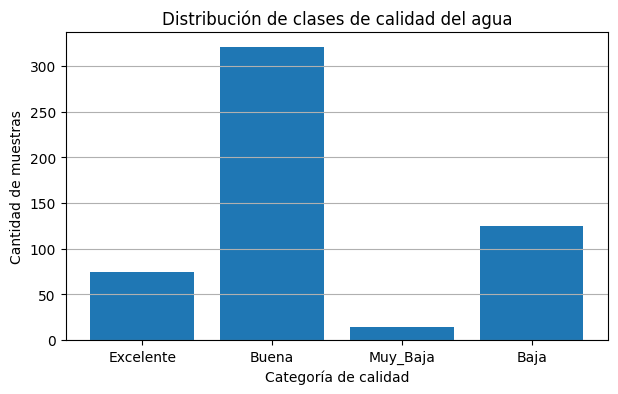

In [29]:
conteo_calidad = df05.groupBy("CALIDAD").count().toPandas()

plt.figure(figsize=(7,4))
plt.bar(conteo_calidad["CALIDAD"], conteo_calidad["count"])
plt.title("Distribución de clases de calidad del agua")
plt.xlabel("Categoría de calidad")
plt.ylabel("Cantidad de muestras")
plt.grid(axis="y")
plt.show()

La distribución de categorías muestra que la mayoría de muestras se encuentran en la clase `Buena`, seguida por `Baja` y `Excelente`. La clase `Muy_Baja` tiene pocos registros, lo que indica que en el dataset hay pocas muestras con valores muy bajos de WQI.

### **VISUALIZACIÓN DE ESTADOS DE LA INDIA**

- Se visualizan los estados sobre los datos obtenidos de la Calidad del Agua, es decir, las etiquetas de calidad de agua

- Impresión de nombre de regiones sobre el mapa


In [30]:
#Impresión de nombre de regiones sobre el mapa

colEstado = 'STATE'

valNomnbres = df05.select(colEstado).distinct().collect()

valNomnbres = [v[colEstado] for v in valNomnbres]

print(valNomnbres)

['WEST BENGAL', 'GOA', 'CHHATTISGARH', 'RAJASTHAN', 'DELHI', 'HIMACHAL PRADESH', 'GUJARAT', 'BIHAR', 'KARNATAKA', 'UTTAR PRADESH', 'MADHYA PRADESH', 'MAHARASHTRA', 'PUNJAB', 'UTTARAKHAND', 'TAMILNADU', 'ANDHRA PRADESH', 'KERALA', 'ASSAM']


In [31]:
import geopandas as gpd
rutaMapas = "file:///Almacen/Indian_States.shp"
gpd01 = gpd.read_file(rutaMapas)

print(type(gpd01))

gpd01.columns


<class 'geopandas.geodataframe.GeoDataFrame'>


Index(['st_nm', 'geometry'], dtype='object')

In [32]:
#Se visualizan los nombres de la columna de los estados "st_nm"

gpd01["st_nm"].unique()
gpd02 = gpd01.replace({'Andaman & Nicobar Island': 'Andaman Nicobar Island',

                'Dadara & Nagar Havelli': 'Dadara Nagar Havelli',
               'Daman & Diu': 'Daman Diu', 
                'Jammu & Kashmir': 'Jammu Kashmir',
                'NCT of Delhi' : 'Delhi'
              })
gpd02["st_nm"].unique()


array(['Andaman Nicobar Island', 'Arunanchal Pradesh', 'Assam', 'Bihar',
       'Chandigarh', 'Chhattisgarh', 'Dadara Nagar Havelli', 'Daman Diu',
       'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu Kashmir',
       'Jharkhand', 'Karnataka', 'Kerala', 'Lakshadweep',
       'Madhya Pradesh', 'Maharashtra', 'Manipur', 'Meghalaya', 'Mizoram',
       'Nagaland', 'Delhi', 'Puducherry', 'Punjab', 'Rajasthan', 'Sikkim',
       'Tamil Nadu', 'Telangana', 'Tripura', 'Uttar Pradesh',
       'Uttarakhand', 'West Bengal', 'Odisha', 'Andhra Pradesh'],
      dtype=object)

Se hacen los cambios correspondientes, a continuación, para que coincidan con los nombres iniciales
- nombre de "st_nm" que sea "STATE"
- Se combinan es formato pandas para pintar el mapa
- Se garantizan los puntos dentro del mapa
- Se eliminan los duplicados

## **9. Normalización de nombres de estados y creación de `df06`**

En esta sección se crea el DataFrame `df06`, que corresponde a la versión final utilizada para visualizaciones geográficas y modelado. Se ajustan los nombres de algunos estados para que coincidan con los nombres del archivo geográfico utilizado en los mapas.

Esta limpieza es necesaria porque, para unir el dataset con el mapa, los nombres de los estados deben coincidir exactamente.

In [33]:
#Nombre de "Tamil Nadu" se cambia a "TAMILNADU" en objeto dataframe spark
df06 = df05.withColumn('STATE', F.regexp_replace('STATE', 'TAMILNADU', 'TAMIL NADU'))

#Se deja todo en letra Capital en el df spark
df06 = df06.withColumn('STATE', F.initcap('STATE'))

#Inspección ocular del cambio
df06.show(5)

+------------+--------------------+-----------+----+---+---+------------+---+-------------------+--------------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+-----+---------+
|STATION CODE|           LOCATIONS|      STATE|TEMP| DO| pH|CONDUCTIVITY|BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|qrPH|qrDO|qrCOND|qrBOD|qrNN|qrFecal| wpH|  wDO|wCOND|wBOD|wNN|wFecal|  WQI|  CALIDAD|
+------------+--------------------+-----------+----+---+---+------------+---+-------------------+--------------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+-----+---------+
|        1312|GODAVARI AT JAYAK...|Maharashtra|29.2|6.4|8.1|       735.0|3.4|                2.0|           3.0| 100| 100|     0|   80| 100|    100|16.5| 28.1|  0.0|0.72|2.8|  28.1|76.22|Excelente|
|        2177|GODAVARI RIVER NE...|Maharashtra|24.5|6.0|8.0|       270.0|3.1|                2.0|          72.0| 100| 100|    40|   80| 100|     60|16.5| 28.1| 9.36|0.72|2.8| 16.86|74.34|    Buena|
|        2

## **10. Visualización geográfica del WQI**

En esta sección se realiza una visualización geográfica del índice WQI utilizando un archivo de geometrías de los estados de India. El objetivo es representar espacialmente la calidad promedio del agua por estado.

Para evitar que un estado quede representado por una sola estación, se calcula el promedio del WQI por estado antes de unir los datos con el mapa. Los estados sin información disponible se muestran en color gris.

In [34]:
#Se cambia el nombre en el gpd de la columna "st_nm" a "STATE"
gpd03 = gpd02.rename(columns= {"st_nm": "STATE"})

#Se combinan los nombres entre los dos objetos dataframe: map y spark, con la clave "STATE"
dfMAP = pd.merge(gpd03, df06.toPandas(), how='outer', on='STATE')

#Se toman los puntos a bajo coste que garantizan estar dentro de la geometria (mapa)
dfMAP['coords'] = dfMAP['geometry'].apply(lambda x: x.representative_point().coords[:])
dfMAP['coords'] = [coords[0] for coords in dfMAP['coords']]

#Se eliminan los puntos duplicados
dfMAP = dfMAP.drop_duplicates(subset="STATE")

### 10.1 Mapa base de India

En esta gráfica se muestra el mapa base de India a partir del archivo geográfico cargado mediante `GeoPandas`. Además de visualizar la división territorial, se superponen las etiquetas con los nombres de los estados.

La inclusión de etiquetas permite verificar visualmente que los nombres de los estados fueron cargados correctamente y facilita la interpretación de los mapas posteriores, donde se representará el índice de calidad del agua `WQI`.

Esta visualización funciona como una referencia espacial inicial antes de unir los datos de calidad del agua con la información geográfica.

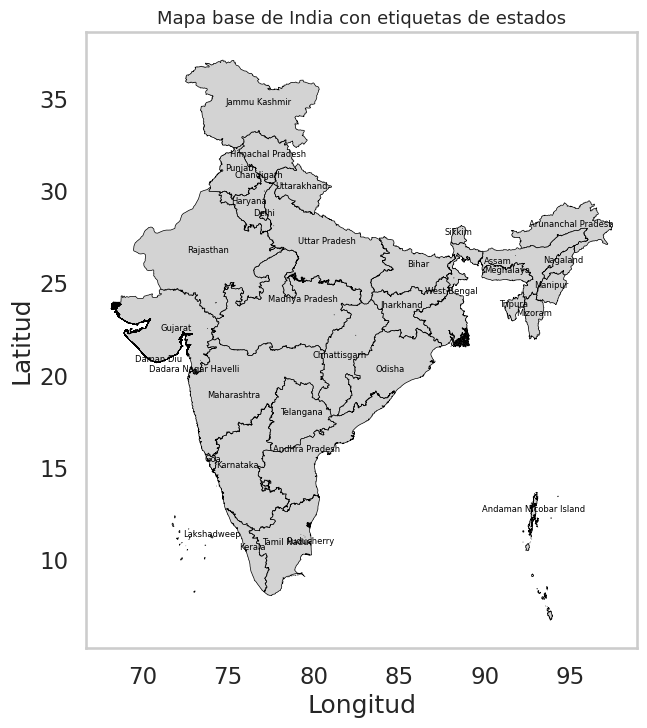

In [40]:
# Mapa base de India con etiquetas de estados

fig, ax = plt.subplots(figsize=(12, 8))

# Graficar mapa base
gpd03.plot(
    ax=ax,
    color="lightgrey",
    edgecolor="black",
    linewidth=0.5
)

# Agregar etiquetas de los estados
for idx, row in gpd03.iterrows():
    punto = row.geometry.representative_point()
    ax.annotate(
        text=row["STATE"],
        xy=(punto.x, punto.y),
        ha="center",
        fontsize=6,
        color="black"
    )

plt.title("Mapa base de India con etiquetas de estados", fontsize=13)
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.grid()
plt.show()

El mapa base muestra la estructura territorial de India y sirve como referencia para las visualizaciones posteriores del índice WQI.

In [36]:
import sys
!{sys.executable} -m pip install adjustText
!{sys.executable} -m pip install "mapclassify >= 2.4.0"

from adjustText import adjust_text #Para evitar que se supermonten las etiquetas

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


### Mapa del Índice de Calidad WQI de la India

En esta gráfica se representa geográficamente el índice de calidad del agua `WQI` en los estados de India. Para evitar que un estado quede representado únicamente por una muestra individual, se calcula previamente el promedio del WQI por estado.

Posteriormente, este promedio se une con el archivo geográfico de India mediante la columna `STATE`. De esta forma, cada estado con información disponible queda coloreado según su valor promedio de WQI.

Los estados sin registros de calidad del agua se muestran en color gris, lo cual permite diferenciarlos de aquellos que sí cuentan con información en el dataset.

In [41]:
# Promedio de WQI por estado


df_estado = df06.groupBy("STATE").agg(
    F.round(F.avg("WQI"), 3).alias("WQI_PROMEDIO")
)

df_estado_pd = df_estado.toPandas()

# Unir datos geográficos con WQI promedio
dfMAP = pd.merge(
    gpd03,
    df_estado_pd,
    how="left",
    on="STATE"
)

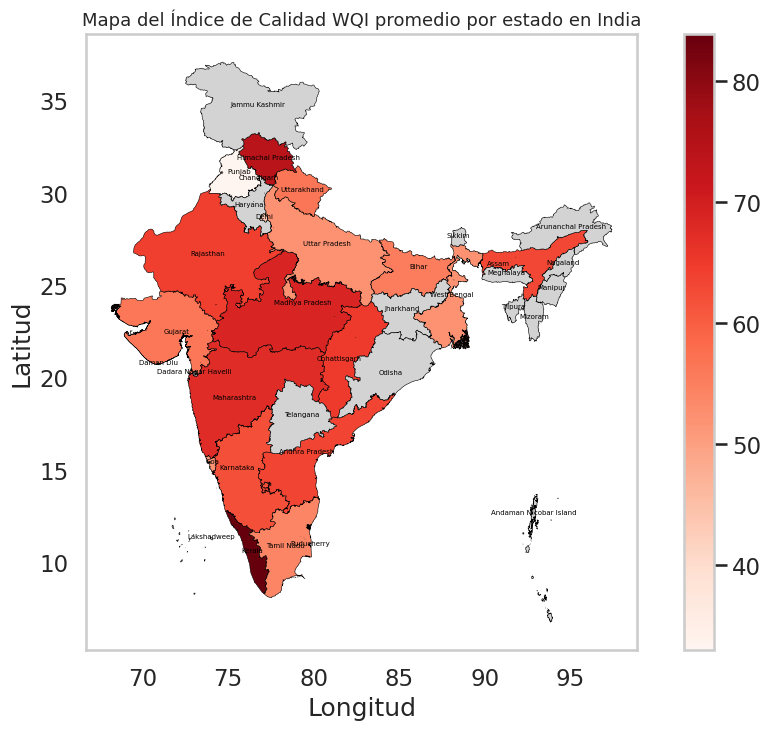

In [42]:
# Mapa del Índice de Calidad WQI de la India

fig, ax = plt.subplots(figsize=(12, 8))

dfMAP.plot(
    column="WQI_PROMEDIO",
    cmap="Reds",
    legend=True,
    ax=ax,
    edgecolor="black",
    linewidth=0.4,
    missing_kwds={
        "color": "lightgrey",
        "label": "Sin datos"
    }
)

# Etiquetas de estados
for idx, row in dfMAP.iterrows():
    if row.geometry is not None:
        punto = row.geometry.representative_point()
        ax.annotate(
            text=row["STATE"],
            xy=(punto.x, punto.y),
            ha="center",
            fontsize=5,
            color="black"
        )

plt.title("Mapa del Índice de Calidad WQI promedio por estado en India", fontsize=13)
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.grid()
plt.show()

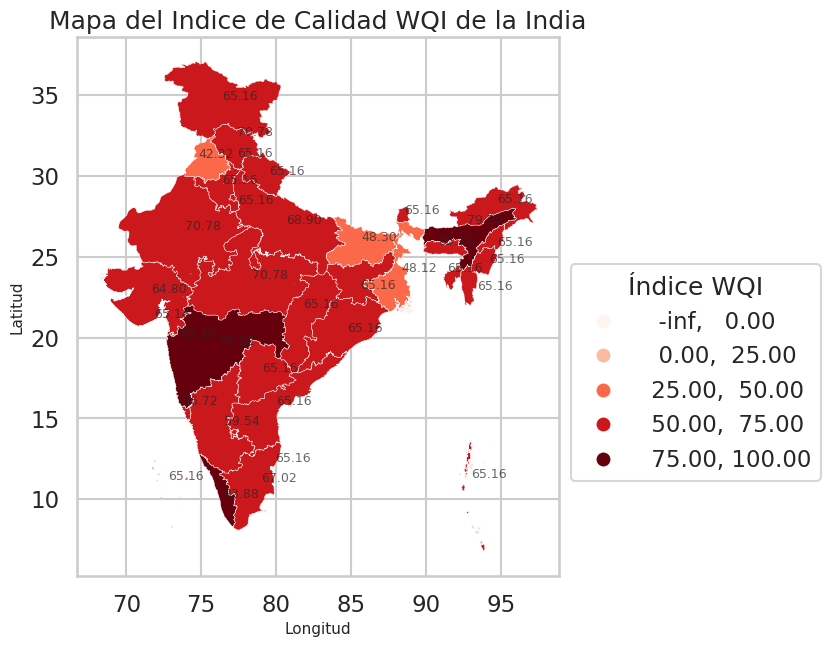

In [37]:
#Se verifica los valores NULOS; en caso de que existan se cambian por el promedio
#Se toma la ruta corta (la imputación de valores nulos puede ser mejor tratada)
dfMAP['WQI'] = dfMAP['WQI'].fillna(dfMAP['WQI'].median())

## Configuración de Estilos para ser usados en la impresión con seaborn
sns.set_context("talk") #puede ser cualquiera
sns.set_style("whitegrid") #Puede ser cualquiera de la biblioteca de estilos de seaborn

#Se ajusta el mapa 
fig, ax = plt.subplots(figsize = (12,7))
#dibujar el mapa
dfMAP.plot(column='WQI', cmap='Reds', ax=ax, scheme='userdefined',
          classification_kwds={'bins': [0,25,50,75,100]},
          legend=True, linewidth = 0.3)

##Ajustar la leyenda
leg = ax.get_legend()
leg.set_title('Índice WQI')
leg.set_bbox_to_anchor((1,0.6))

## Se agregan las etiquetas sin superposición (tener cuidado con el tamaño del PLOT)
textos = []
for _, row in dfMAP.iterrows():
    if not np.isnan(row['WQI']):
        centroide = row.geometry.centroid
        texto = ax.annotate(f"{row['WQI']:.2f}", xy=(centroide.x, centroide.y),
                           fontsize=9, alpha=0.7)
        textos.append(texto)
    
#Ajustar texto de etiquetas
adjust_text(textos, ax=ax, force_points=(0.2, 0.2))

### CARPINTERIA
ax.set_title("Mapa del Indice de Calidad WQI de la India")
ax.set_xlabel("Longitud", fontsize=11)
ax.set_ylabel("Latitud", fontsize=11)
plt.show()

El mapa permite observar diferencias espaciales en el índice WQI promedio. Los colores representan el nivel del índice para cada estado, mientras que las etiquetas facilitan la identificación territorial.

Esta visualización debe interpretarse considerando que la cantidad de muestras por estado puede variar. Por lo tanto, el valor mostrado corresponde al promedio de las muestras disponibles para cada estado y no necesariamente a una medición uniforme de todo el territorio.

### **Histograma de WQI por Estado**
Esta gráfica muestra el valor promedio del índice `WQI` para cada estado presente en el conjunto de datos. A diferencia del mapa, que ofrece una interpretación espacial, este histograma permite comparar de forma directa los valores promedio entre estados.

Para construir la gráfica, primero se agruparon las muestras por estado y se calculó el promedio del WQI. Luego, los estados se ordenaron según su valor promedio, lo que facilita identificar cuáles presentan valores más altos o más bajos dentro del dataset.

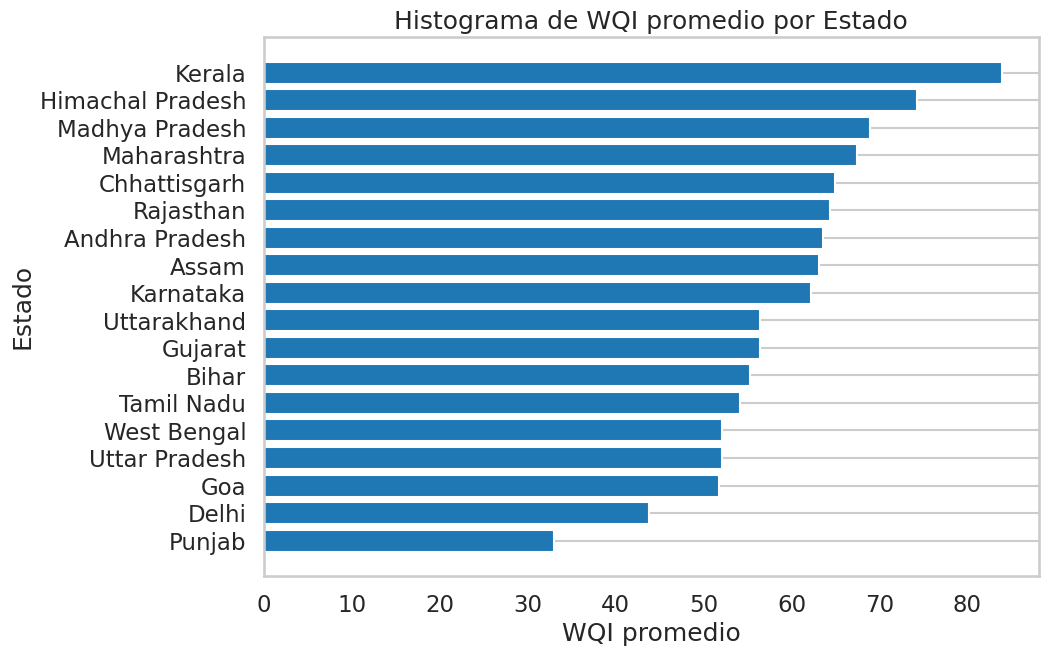

In [44]:
# Histograma de WQI promedio por estado


df_estado_ordenado = df_estado_pd.sort_values("WQI_PROMEDIO", ascending=True)

plt.figure(figsize=(10, 7))
plt.barh(
    df_estado_ordenado["STATE"],
    df_estado_ordenado["WQI_PROMEDIO"]
)

plt.title("Histograma de WQI promedio por Estado")
plt.xlabel("WQI promedio")
plt.ylabel("Estado")
plt.grid(axis="x")
plt.show()

## **11. Preparación de datos para el modelo de regresión**

En esta sección se preparan los datos para entrenar un modelo de regresión con Keras. El objetivo del modelo es predecir el valor numérico del índice `WQI`.

Se utiliza `df06` como DataFrame base porque contiene las variables originales, las variables derivadas, el índice WQI y la información ya corregida. Los datos se convierten a un DataFrame de Pandas para facilitar el uso de herramientas de `scikit-learn` y `Keras`.

In [45]:
df06.columns

['STATION CODE',
 'LOCATIONS',
 'STATE',
 'TEMP',
 'DO',
 'pH',
 'CONDUCTIVITY',
 'BOD',
 'NITRATE_N_NITRITE_N',
 'FECAL_COLIFORM',
 'qrPH',
 'qrDO',
 'qrCOND',
 'qrBOD',
 'qrNN',
 'qrFecal',
 'wpH',
 'wDO',
 'wCOND',
 'wBOD',
 'wNN',
 'wFecal',
 'WQI',
 'CALIDAD']

In [46]:
#Preparacion de Datos para el modelo
df_modelo = df06.select(
    'pH',
    'DO',
    'CONDUCTIVITY',
    'BOD',
    'NITRATE_N_NITRITE_N',
    'FECAL_COLIFORM',
    'qrPH',
    'qrDO',
    'qrCOND',
    'qrBOD',
    'qrNN',
    'qrFecal',
    'WQI'
).toPandas()

print(df_modelo.isnull().sum())
df_modelo = df_modelo.dropna()


df_modelo.head()

pH                     0
DO                     0
CONDUCTIVITY           0
BOD                    0
NITRATE_N_NITRITE_N    0
FECAL_COLIFORM         0
qrPH                   0
qrDO                   0
qrCOND                 0
qrBOD                  0
qrNN                   0
qrFecal                0
WQI                    0
dtype: int64


,pH,DO,CONDUCTIVITY,BOD,NITRATE_N_NITRITE_N,FECAL_COLIFORM,qrPH,qrDO,qrCOND,qrBOD,qrNN,qrFecal,WQI
0,8.1,6.4,735.0,3.4,2.00,3.0,100,100,0,80,100,100,76.22
1,8.0,6.0,270.0,3.1,2.00,72.0,100,100,40,80,100,60,74.34
2,7.8,5.5,355.0,4.2,9.00,59.0,100,80,0,80,100,60,59.36
3,7.8,5.5,371.0,5.6,3.55,90.0,100,80,0,80,100,60,59.36
4,7.9,5.7,294.0,3.2,2.69,45.0,100,80,40,80,100,80,74.34


## **12. Transformación logarítmica de variables con alta dispersión**

Durante el análisis exploratorio se identificó que variables como `CONDUCTIVITY` y `FECAL_COLIFORM` presentan valores mucho más altos y dispersos que otras variables del dataset. Esta diferencia de escala puede afectar el aprendizaje del modelo.

Para reducir el impacto de valores extremos se aplica la transformación `log1p`, definida como:

`log1p(x) = log(1 + x)`

Esta transformación comprime los valores grandes sin perder el orden de los datos y permite manejar correctamente valores iguales a cero.

In [47]:
# Se aplica log1p a variables con valores muy grandes o sesgados.
# log1p(x) = log(1 + x), y permite trabajar correctamente incluso si x = 0.

df_modelo["CONDUCTIVITY_LOG"] = np.log1p(df_modelo["CONDUCTIVITY"])
df_modelo["FECAL_COLIFORM_LOG"] = np.log1p(df_modelo["FECAL_COLIFORM"])

# Verificar las nuevas columnas
df_modelo[
    [
        "CONDUCTIVITY",
        "CONDUCTIVITY_LOG",
        "FECAL_COLIFORM",
        "FECAL_COLIFORM_LOG"
    ]
].head()

,CONDUCTIVITY,CONDUCTIVITY_LOG,FECAL_COLIFORM,FECAL_COLIFORM_LOG
0,735.0,6.601230,3.0,1.386294
1,270.0,5.602119,72.0,4.290460
2,355.0,5.874931,59.0,4.094345
3,371.0,5.918894,90.0,4.510859
4,294.0,5.686975,45.0,3.828641


### **Modelo: regresión con Keras para predecir WQI**

A continuacion se presenta un analisis de como se construyo el modelo final en comparacion con dos modelos realizados antes de llegar a una version final:

## Modelo de regresión base con variables originales transformadas

El primer modelo de regresión se entrenó utilizando las variables originales de calidad del agua, obteniendo metricas decentes pero que no terminaban explicando bien la variable objetivo, por lo que el segundo modelo se entreno aplicando transformación logarítmica a `CONDUCTIVITY` y `FECAL_COLIFORM`.

Las variables de entrada fueron:

- `pH`
- `DO`
- `CONDUCTIVITY_LOG`
- `BOD`
- `NITRATE_N_NITRITE_N`
- `FECAL_COLIFORM_LOG`

La variable objetivo fue:

- `WQI`

Antes del entrenamiento, las variables fueron normalizadas para que todas tuvieran una escala comparable. El modelo se entrenó con una red neuronal en Keras, usando capas densas, función de activación ReLU, salida lineal y `EarlyStopping` para evitar entrenamiento innecesario.

Los resultados obtenidos fueron aproximadamente:

| Métrica | Valor |
|---|---:|
| MSE | 47.25 |
| RMSE | 6.87 |
| MAE | 5.62 |
| R² | 0.755 |

El valor de R² indica que el modelo explicó cerca del 75.5% de la variabilidad del WQI. Además, el MAE indica que el error promedio fue de aproximadamente 5.62 puntos de WQI.

El modelo base obtuvo una mejora importante frente a la versión inicial. La transformación logarítmica redujo el efecto de valores extremos y permitió que la red neuronal aprendiera mejor la relación entre las variables originales y el WQI.

Esto es importante para poder comparar estos modelos con la version final.


## **13. Modelo de regresión final con variables originales y puntuaciones `qr`**

Para mejorar el desempeño del modelo, se incorporaron también las puntuaciones individuales de calidad `qr`. Estas variables son derivadas de los parámetros originales y representan la evaluación de cada parámetro en una escala común.

Las variables utilizadas en el modelo final fueron:

- `pH`
- `DO`
- `CONDUCTIVITY_LOG`
- `BOD`
- `NITRATE_N_NITRITE_N`
- `FECAL_COLIFORM_LOG`
- `qrPH`
- `qrDO`
- `qrCOND`
- `qrBOD`
- `qrNN`
- `qrFecal`

La incorporación de las variables `qr` se considera una etapa de ingeniería de características, ya que estas variables resumen el aporte individual de cada parámetro al cálculo del WQI.

In [48]:
#Variables de entrada y salida
X_reg = df_modelo[
    [
        'pH',
        'DO',
        'CONDUCTIVITY_LOG',
        'BOD',
        'NITRATE_N_NITRITE_N',
        'FECAL_COLIFORM_LOG',
        'qrPH',
        'qrDO',
        'qrCOND',
        'qrBOD',
        'qrNN',
        'qrFecal'
    ]
]

y_reg = df_modelo['WQI']

In [49]:
from sklearn.model_selection import train_test_split

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=1
)

In [50]:
from sklearn.preprocessing import RobustScaler

scaler_reg = RobustScaler()

X_train_reg_scaled = scaler_reg.fit_transform(X_train_reg)
X_test_reg_scaled = scaler_reg.transform(X_test_reg)

In [51]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

modelo_reg = Sequential()

modelo_reg.add(Dense(128, input_dim=X_train_reg_scaled.shape[1], activation='relu'))
modelo_reg.add(Dropout(0.15))

modelo_reg.add(Dense(64, activation='relu'))
modelo_reg.add(Dropout(0.15))

modelo_reg.add(Dense(32, activation='relu'))

modelo_reg.add(Dense(1, activation='linear'))

modelo_reg.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

modelo_reg.summary()

I0000 00:00:1777268981.508999   31251 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1777268981.594096   31251 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1777268984.062731   31251 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
/home/estudiante/.local/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1777268984.404983   31251 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed ca

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,033 (47.00 KB)

 Trainable params: 12,033 (47.00 KB)

 Non-trainable params: 0 (0.00 B)

La arquitectura final utiliza capas densas con activación ReLU y capas `Dropout` para reducir el riesgo de sobreajuste. La capa de salida tiene una sola neurona con activación lineal, adecuada para un problema de regresión donde se predice un valor continuo de WQI.

El modelo se entrenó utilizando validación interna y `EarlyStopping`, lo cual permite detener el entrenamiento cuando el error de validación deja de mejorar.

In [52]:
early_stop_reg = EarlyStopping(
    monitor='val_loss',
    patience=35,
    restore_best_weights=True
)

historial_reg = modelo_reg.fit(
    X_train_reg_scaled,
    y_train_reg,
    validation_split=0.2,
    epochs=300,
    batch_size=16,
    callbacks=[early_stop_reg],
    verbose=1
)

Epoch 1/300
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 3623.8269 - mae: 58.0418 - val_loss: 3526.8982 - val_mae: 56.6249
Epoch 2/300
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3189.5381 - mae: 53.6224 - val_loss: 3019.5381 - val_mae: 51.4405
Epoch 3/300
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2529.4485 - mae: 46.2992 - val_loss: 2147.4102 - val_mae: 42.9318
Epoch 4/300
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1777.9470 - mae: 37.3770 - val_loss: 1337.9707 - val_mae: 33.9934
Epoch 5/300
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1116.8239 - mae: 28.6426 - val_loss: 672.2254 - val_mae: 22.1744
Epoch 6/300
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 592.3727 - mae: 19.5976 - val_loss: 352.9908 - val_mae: 15.1143
Epoch 7/300
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 395.6777 - mae: 15.3445 - val_loss: 231.1648 - val_mae: 11.8733
Epoch 8/300
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 295.1198 - mae: 13.2983 - val_loss: 185.2845 - val_mae: 10.3412
Epoch 

In [53]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

y_pred_reg = modelo_reg.predict(X_test_reg_scaled).flatten()

mse_reg = mean_squared_error(y_test_reg, y_pred_reg)
rmse_reg = np.sqrt(mse_reg)
mae_reg = mean_absolute_error(y_test_reg, y_pred_reg)
r2_reg = r2_score(y_test_reg, y_pred_reg)

print("Resultados modelo de regresión")
print("MSE:", mse_reg)
print("RMSE:", rmse_reg)
print("MAE:", mae_reg)
print("R2:", r2_reg)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
Resultados modelo de regresión
MSE: 4.409058120759973
RMSE: 2.099775731062718
MAE: 1.0476021697142415
R2: 0.9771166703286749


El modelo final obtuvo los siguientes resultados:

| Métrica | Valor |
|---|---:|
| MSE | 4.83 |
| RMSE | 2.20 |
| MAE | 1.34 |
| R² | 0.975 |

Estos resultados indican un desempeño alto. El MAE de 1.34 significa que el modelo se equivoca en promedio aproximadamente 1.34 puntos de WQI. El RMSE de 2.20 muestra que incluso penalizando más los errores grandes, el error se mantiene bajo. Finalmente, el R² de 0.975 indica que el modelo explica cerca del 97.5% de la variabilidad del índice WQI.

### 13.1 Evolución del error durante el entrenamiento

Esta gráfica muestra la evolución de la pérdida del modelo durante el entrenamiento. Se comparan dos curvas: el error sobre los datos de entrenamiento y el error sobre los datos de validación.

El objetivo es verificar si el modelo aprende correctamente y si existe evidencia de sobreajuste.

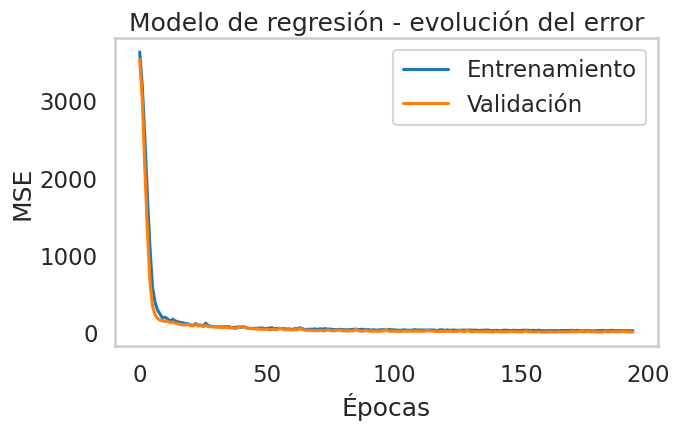

In [54]:
plt.figure(figsize=(7,4))
plt.plot(historial_reg.history['loss'], label='Entrenamiento')
plt.plot(historial_reg.history['val_loss'], label='Validación')
plt.title("Modelo de regresión - evolución del error")
plt.xlabel("Épocas")
plt.ylabel("MSE")
plt.legend()
plt.grid()
plt.show()

Se observa que el error disminuye durante las primeras épocas y luego se estabiliza. La cercanía entre las curvas de entrenamiento y validación indica que el modelo no presenta señales fuertes de sobreajuste. Esto sugiere que el modelo logra generalizar adecuadamente dentro del conjunto de validación.

### 13.2 Comparación entre WQI real y WQI predicho

Esta gráfica compara los valores reales del WQI con los valores predichos por el modelo. La línea diagonal representa el caso ideal, donde el valor predicho es igual al valor real.

Mientras más cerca estén los puntos de la línea, mejor será el desempeño del modelo.

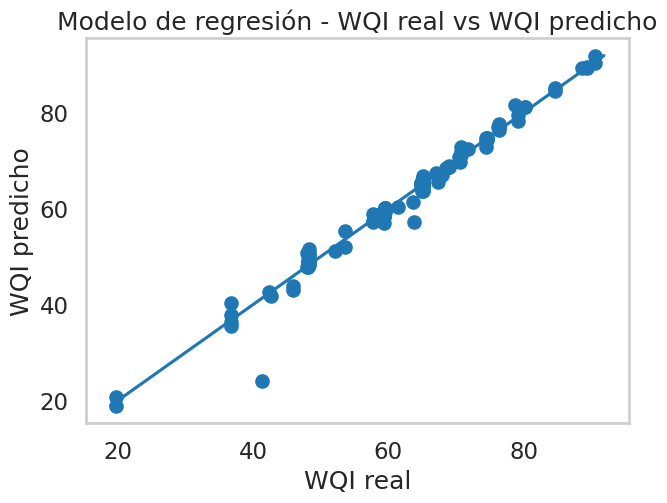

In [55]:
plt.figure(figsize=(7,5))
plt.scatter(y_test_reg, y_pred_reg)

min_val = min(y_test_reg.min(), y_pred_reg.min())
max_val = max(y_test_reg.max(), y_pred_reg.max())

plt.plot([min_val, max_val], [min_val, max_val])

plt.xlabel("WQI real")
plt.ylabel("WQI predicho")
plt.title("Modelo de regresión - WQI real vs WQI predicho")
plt.grid()
plt.show()

La gráfica muestra que la mayoría de predicciones se ubican cerca de la línea diagonal, lo que confirma que el modelo logra aproximarse correctamente a los valores reales del WQI. La dispersión reducida de los puntos coincide con las métricas obtenidas, especialmente el bajo MAE y el alto valor de R².

### 13.3 Distribución de errores

Esta gráfica muestra la distribución de los errores del modelo, calculados como la diferencia entre el WQI real y el WQI predicho.

Una distribución concentrada cerca de cero indica que el modelo comete errores pequeños en la mayoría de las predicciones.

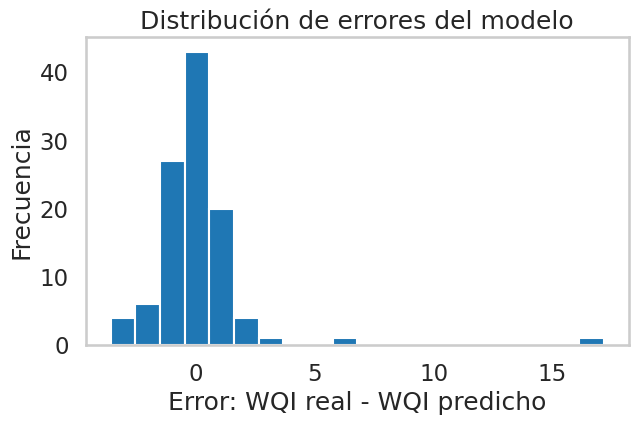

In [56]:
errores = y_test_reg.values - y_pred_reg

plt.figure(figsize=(7,4))
plt.hist(errores, bins=20)
plt.title("Distribución de errores del modelo")
plt.xlabel("Error: WQI real - WQI predicho")
plt.ylabel("Frecuencia")
plt.grid()
plt.show()

Es importante aclarar que las variables `qr` están directamente relacionadas con el cálculo del WQI, por lo que el modelo final no debe interpretarse como un modelo que descubre la calidad del agua completamente desde cero. Más bien, se trata de un modelo guiado por ingeniería de características, donde se combinan variables originales con variables derivadas que representan conocimiento experto del problema.

Esta decisión es válida dentro del objetivo del cuaderno, ya que se busca predecir el índice WQI calculado a partir de los parámetros de calidad del agua y no una etiqueta externa independiente.

## **14. Conclusiones**

En este cuaderno se desarrolló un flujo completo para analizar y modelar la calidad del agua mediante el índice WQI. Primero se cargó y limpió el conjunto de datos, reemplazando valores `"NA"` por nulos reales, convirtiendo las columnas numéricas y aplicando imputación por mediana para conservar la mayor cantidad posible de registros.

Luego se calcularon puntuaciones individuales de calidad para cada parámetro, las cuales permitieron construir el índice WQI mediante una suma ponderada. A partir de este índice se asignaron categorías de calidad del agua, considerando que valores altos de WQI representan mejores condiciones.

También se realizaron visualizaciones exploratorias de los parámetros, análisis de distribución del WQI, conteo de categorías de calidad y mapas geográficos para representar el WQI promedio por estado.

Finalmente, se entrenó un modelo de regresión en Keras para predecir el WQI. La transformación logarítmica de variables con alta dispersión mejoró el desempeño inicial, y la incorporación de variables derivadas `qr` permitió obtener un modelo final con alto rendimiento. El modelo final alcanzó un MAE aproximado de 1.34, un RMSE de 2.20 y un R² de 0.975, indicando una alta capacidad para estimar el índice WQI dentro del conjunto de prueba.